In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [6]:
# ---- STEP 1: LOAD & ENGINEER FEATURES ----
df = pd.read_csv('sales_data.csv')

# Ensure date column is parsed correctly
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'])

# Engineer key business metrics
df['Total_Cost'] = df['Quantity_Sold'] * df['Unit_Cost']
df['Net_Profit'] = df['Sales_Amount'] - df['Total_Cost']

print("--- Dataset Structure ---")
print(df.head())

--- Dataset Structure ---
   Product_ID  Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052 2023-02-03       Bob  North       5053.97             18   
1        1093 2023-04-21       Bob   West       4384.02             17   
2        1015 2023-09-21     David  South       4631.23             30   
3        1072 2023-08-24       Bob  South       2167.94             39   
4        1061 2023-03-24   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  Total_Cost  Net_Profit  
0           Cash        Online      

/tmp/ipykernel_10414/2789132428.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Product_Category', y='Sales_Amount', estimator=sum, errorbar=None, palette='muted', ax=axes[0, 0])
/tmp/ipykernel_10414/2789132428.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Region', y='Sales_Amount', estimator=sum, errorbar=None, palette='magma', ax=axes[0, 2])


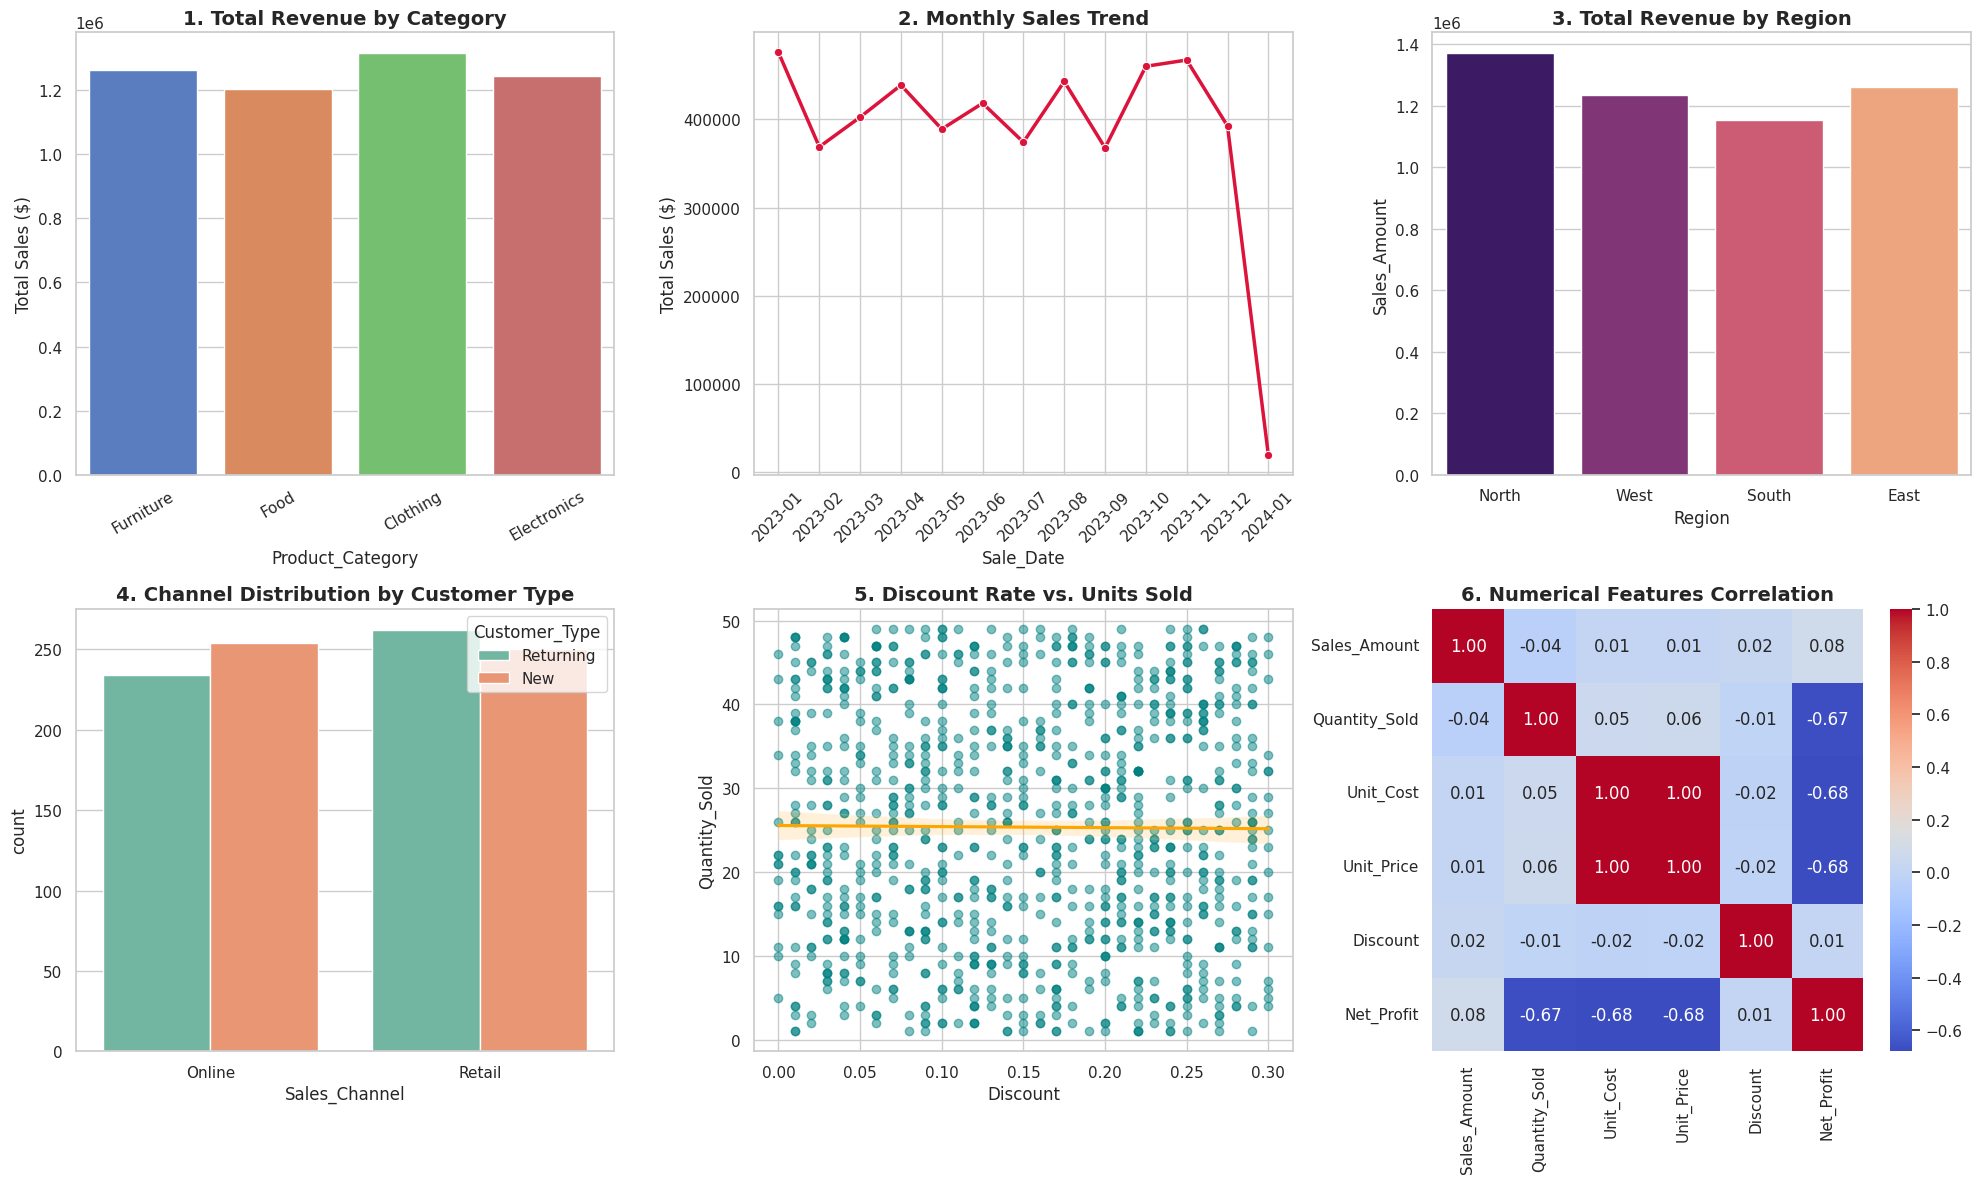

In [7]:
# ---- STEP 2: DATA VISUALIZATION (5 EXPLORATORY PLOTS) ----
# Setting up a 2-row, 3-column grid for 5 clean charts
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
sns.set_theme(style="whitegrid")

# Plot 1: Total Revenue by Product Category (Bar)
sns.barplot(data=df, x='Product_Category', y='Sales_Amount', estimator=sum, errorbar=None, palette='muted', ax=axes[0, 0])
axes[0, 0].set_title('1. Total Revenue by Category', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=30)
axes[0, 0].set_ylabel('Total Sales ($)')

# Plot 2: Historical Sales Trend Over Time (Line) - FIXED TYPO HERE
trend_df = df.groupby(df['Sale_Date'].dt.strftime('%Y-%m'))['Sales_Amount'].sum().reset_index()
sns.lineplot(data=trend_df, x='Sale_Date', y='Sales_Amount', marker='o', color='crimson', linewidth=2.5, ax=axes[0, 1])
axes[0, 1].set_title('2. Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].set_ylabel('Total Sales ($)')

# Plot 3: Revenue Distribution by Region (Bar)
sns.barplot(data=df, x='Region', y='Sales_Amount', estimator=sum, errorbar=None, palette='magma', ax=axes[0, 2])
axes[0, 2].set_title('3. Total Revenue by Region', fontsize=14, fontweight='bold')

# Plot 4: Sales Channel vs Customer Type Breakdown (Grouped Count)
sns.countplot(data=df, x='Sales_Channel', hue='Customer_Type', palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('4. Channel Distribution by Customer Type', fontsize=14, fontweight='bold')

# Plot 5: Discount Rate vs Quantity Sold (Scatter with Trendline)
sns.regplot(data=df, x='Discount', y='Quantity_Sold', scatter_kws={'alpha':0.5, 'color':'teal'}, line_kws={'color':'orange'}, ax=axes[1, 1])
axes[1, 1].set_title('5. Discount Rate vs. Units Sold', fontsize=14, fontweight='bold')

# Plot 6: Correlation Heatmap among Key Performance Metrics
numerical_cols = ['Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount', 'Net_Profit']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", cbar=True, ax=axes[1, 2])
axes[1, 2].set_title('6. Numerical Features Correlation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# ---- STEP 3: PREPARE DATA FOR ML ----
# Drop columns that act as unique identifiers or are target-leaking
X = df.drop(columns=['Product_ID', 'Sale_Date', 'Sales_Amount', 'Net_Profit', 'Region_and_Sales_Rep'])
y = df['Sales_Amount']

# One-Hot Encode all categorical columns safely
X = pd.get_dummies(X, drop_first=True, dtype=int)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [9]:
# ---- STEP 4: MODEL TRAINING & EVALUATION ----
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [10]:
# ---- STEP 5: FEATURE IMPORTANCE ----
importances = model.feature_importances_
indices = np.argsort(importances)[-5:]

# Display Text Performance Results
print("\n=== ML MODEL PERFORMANCE SUMMARY ===")
performance_metrics = pd.DataFrame({
    'Metric': ['R² Score (Accuracy)', 'Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)'],
    'Value': [f"{r2:.4f}", f"${mae:.2f}", f"${rmse:.2f}"]
})
print(performance_metrics.to_string(index=False))

print("\n--- Top 5 Most Influential Features Predicting Sales ---")
for i in reversed(indices):
    print(f"• {X.columns[i]}: {importances[i]*100:.2f}% influence")


=== ML MODEL PERFORMANCE SUMMARY ===
                        Metric    Value
           R² Score (Accuracy)  -0.0835
     Mean Absolute Error (MAE) $2768.65
Root Mean Squared Error (RMSE) $3164.34

--- Top 5 Most Influential Features Predicting Sales ---
• Total_Cost: 16.44% influence
• Unit_Cost: 15.37% influence
• Unit_Price: 14.70% influence
• Discount: 13.90% influence
• Quantity_Sold: 12.48% influence


/tmp/ipykernel_10414/4068277994.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')


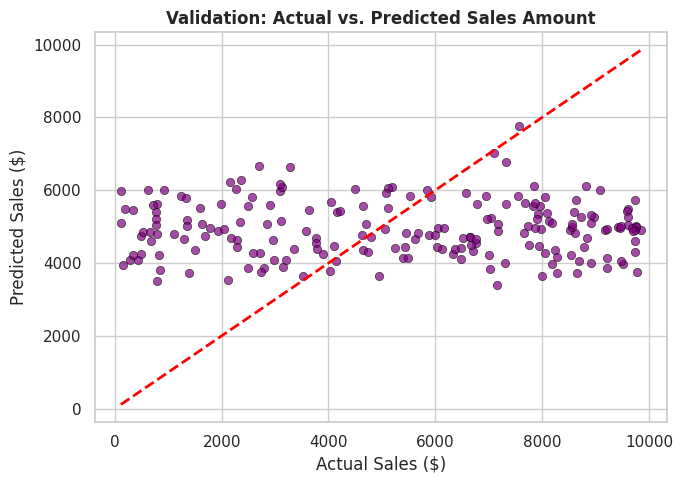

In [11]:
# ---- STEP 6: MODEL PERFORMANCE PLOT (PLOT #7 - BONUS VALIDATION) ----
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='purple', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, color='red')
plt.title('Validation: Actual vs. Predicted Sales Amount', fontsize=12, fontweight='bold')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.tight_layout()
plt.show()